<a href="https://colab.research.google.com/github/lorenqueralt/Clasificacion-Binaria-Top-10-F1---DSI/blob/main/Proyecto_Final_DSI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto Final Data Science I**
# *Predicción de finalización en el Top 10 en Fórmula 1 (1994–2024)*

---

*Tipo de problema:* Clasificación binaria
Problema: dado un piloto que larga una carrera, ¿terminará dentro del top 10?

*Dataset:* datos históricos de Formula 1 (base Ergast discontinuada). Usando los datos de la era moderna (1994-2024).

*Contexto:* solo se usan variables conocidas antes de la largada. Quedan excluidas variables que se desarrollan durante o después de la carrera.

# 0. Setup del modelo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibilidad: defino semilla
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.dpi"] = 200

# 1. Contexto del problema y dataset

*¿Qué se predice y por qué importa?*

Terminar en el Top 10. Terminar en el Top 10 es el umbral que define sumar puntos en el reglamento actual, y un indicador robusto de rendimiento competitivo para toda la era analizada. Predecir esto es especialmente relevante para los equipos de mitad de tabla, donde entrar o no define la temporada.

*Origen del dataset*

*   Base Ergast (API histórica de F1), obtenida vía Kaggle
*   Periodo 1994 a 2024
*   Fecha de descarga: 08/09/2026
*   Link de descarga: https://www.kaggle.com/datasets/jtrotman/formula-1-race-data
*   estos son datos comunitarios, no oficiales de la FIA/F1


# 2. Descripción del dataset y definición de la variable objetivo

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = "/content/drive/MyDrive/Coderhouse/Data Science I/Proyecto Final/F1 Dataset"

TABLES = ["races","results","drivers","constructors","qualifying",
          "driver_standings","constructor_standings","pit_stops",
          "circuits","status","lap_times","sprint_results","seasons",
          "constructor_results"]

def load(name):
    return pd.read_csv(f"{DATA_DIR}/{name}.csv", na_values=["\\N"])

data = {t: load(t) for t in TABLES}
for t in ["races","results","qualifying","driver_standings","constructor_standings"]:
    print(f"{t:24} {data[t].shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
races                    (1172, 18)
results                  (27524, 18)
qualifying               (11256, 9)
driver_standings         (35649, 7)
constructor_standings    (13774, 7)


## **Diccionario de variables**
---

| Variable | Tabla | Tipo | Significado |
|---|---|---|---|
| `raceId` | varias | clave | Identificador único de carrera |
| `driverId` | varias | clave | Identificador único de piloto |
| `constructorId` | varias | clave | Identificador único de equipo/constructor |
| `circuitId` | races / circuits | clave | Identificador único de circuito |
| `year`, `round` | races | entero | Temporada y número de fecha dentro de la temporada |
| `grid` | results | entero | Posición de largada. **`grid = 0` = largada desde pit lane** (no primera posición). En preprocesamiento se reemplaza por la última posición de la parrilla de esa carrera + 1 |
| `positionOrder` | results | entero | Orden de clasificación final de todos los pilotos (incluye abandonos). Nunca es nulo. Base del target |
| `position` | results | entero / NaN | Posición final oficial; NaN para no clasificados (DNF). No se usa para el target por eso |
| `points` | results | float | Puntos obtenidos en esa carrera (no confundir con los puntos acumulados de standings) |
| `laps` | results | entero | Vueltas completadas. Define "largó" (`laps > 0`) |
| `statusId` / `status` | results / status | clave / texto | Motivo del resultado (Finished, Engine, Collision, etc.) |
| `q1`, `q2`, `q3` | qualifying | texto → seg | Mejor tiempo en cada segmento de clasificación. Formato `M:SS.mmm`. NaN = no participó de ese segmento |
| `points` | driver_standings / constructor_standings | float | Puntos acumulados en el campeonato hasta esa carrera inclusive (distinta de `points` de results). Como feature se usa la foto del round anterior |


## **Diccionario de features del modelo**

| Feature | Tipo | Origen | Definición | Tratamiento en preprocesamiento |
|---|---|---|---|---|
| `grid` | Numérica | `results` | Posición de largada en la carrera. | `grid = 0` (largada desde pit lane) se reemplaza por la última posición de esa carrera + 1. Imputación por mediana (sin faltantes en la práctica) y estandarización. |
| `gap_pct` | Numérica | Derivada de `qualifying` | Diferencia porcentual entre el mejor tiempo de clasificación del piloto (mínimo entre Q1, Q2 y Q3) y el tiempo de la pole de esa sesión. | Tope en 7% (regla del 107%). Imputación por mediana del 15,8% de faltantes, concentrados en 1996–2002. Estandarización. |
| `pts_constructor_norm` | Numérica (0 a 1) | Derivada de `results` | Puntos acumulados del equipo en la temporada **antes** de la carrera actual, divididos por los del equipo líder en ese momento. Vale 0 en la primera fecha. | Imputación por mediana (sin faltantes en la práctica) y estandarización. |
| `experiencia` | Numérica (entera) | Derivada de `results` | Cantidad de carreras disputadas por el piloto **antes** de la carrera actual, contadas sobre toda su historia (desde 1950). Vale 0 en el debut. | Imputación por mediana (sin faltantes en la práctica) y estandarización. |
| `driverId` | Categórica (alta cardinalidad) | `results` | Identificador del piloto. | Target Encoding con smoothing dentro del pipeline, seguido de estandarización. Pilotos no vistos en entrenamiento reciben la media global. |
| `constructorId` | Categórica (47 niveles) | `results` | Identificador del equipo. Cada denominación comercial es una categoría distinta. | Target Encoding con smoothing dentro del pipeline, seguido de estandarización. Equipos no vistos en entrenamiento reciben la media global. |
| `pts_piloto_norm` | Numérica (0 a 1) | Derivada de `results` | Puntos acumulados del piloto en la temporada **antes** de la carrera actual, divididos por los del líder. | **Excluida del modelo** por su correlación de 0,91 con `pts_constructor_norm`. |
| `y` (target) | Binaria | Derivada de `results` | 1 si `positionOrder <= 10` (terminó en el Top 10), 0 en caso contrario. Universo: pilotos que largaron (`laps > 0`), sin descalificados, 1994–2024. | — |

Todas las features se conocen antes de la largada. Las variables históricas se calculan con corte temporal estricto (solo información de carreras anteriores), por lo que no introducen leakage.

## **Variable objetivo**

- **Universo:** pilotos que efectivamente largaron la carrera. Operacionalizado como `laps > 0` (criterio objetivo basado en datos, más robusto que clasificar 108 strings de `status` a mano).
- **Exclusiones:** descalificados (`Disqualified`, `Excluded`, `Underweight`) — no son un resultado deportivo limpio.
- **Ventana temporal:** 1994–2024 (arranque coincide con el inicio de la tabla `qualifying`).
- **Target:** `y = 1` si `positionOrder <= 10`, `0` en caso contrario.

In [ ]:
races  = data["races"]
results= data["results"]
status = data["status"]

# Merge base de datos: resultado + año + status
df = (results
      .merge(races[["raceId","year","round","circuitId"]], on="raceId")
      .merge(status, on="statusId"))

# Tipos numéricos
for c in ["laps","positionOrder","grid"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Ventana temporal
df = df[(df.year >= 1994) & (df.year <= 2024)].copy()

# Exclusiones y universo (largaron, sin DQ)
DQ = ["Disqualified","Excluded","Underweight"]
df = df[~df.status.isin(DQ)]
df = df[df.laps > 0].copy()

# Target
df["y"] = (df.positionOrder <= 10).astype(int)

n = len(df); pos = df.y.sum()
print(f"Filas (piloto-carrera): {n:,}")
print(f"Top 10 (y=1): {pos:,} ({100*pos/n:.1f}%)  |  Fuera Top 10 (y=0): {n-pos:,} ({100*(n-pos)/n:.1f}%)")

df.head(5)

Filas (piloto-carrera): 11,766
Top 10 (y=1): 5,765 (49.0%)  |  Fuera Top 10 (y=0): 6,001 (51.0%)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,round,circuitId,status,y
0,1,18,1,1,22.0,1.0,1.0,1,1,10.0,...,39.0,2.0,1:27.452,218.300,1,2008,1,1,Finished,1
1,2,18,2,2,3.0,5.0,2.0,2,2,8.0,...,41.0,3.0,1:27.739,217.586,1,2008,1,1,Finished,1
2,3,18,3,3,7.0,7.0,3.0,3,3,6.0,...,41.0,5.0,1:28.090,216.719,1,2008,1,1,Finished,1
3,4,18,4,4,5.0,11.0,4.0,4,4,5.0,...,58.0,7.0,1:28.603,215.464,1,2008,1,1,Finished,1
4,5,18,5,1,23.0,3.0,5.0,5,5,4.0,...,43.0,1.0,1:27.418,218.385,1,2008,1,1,Finished,1


# 3. Exploratory Data Analysis (EDA)

## Balance del target

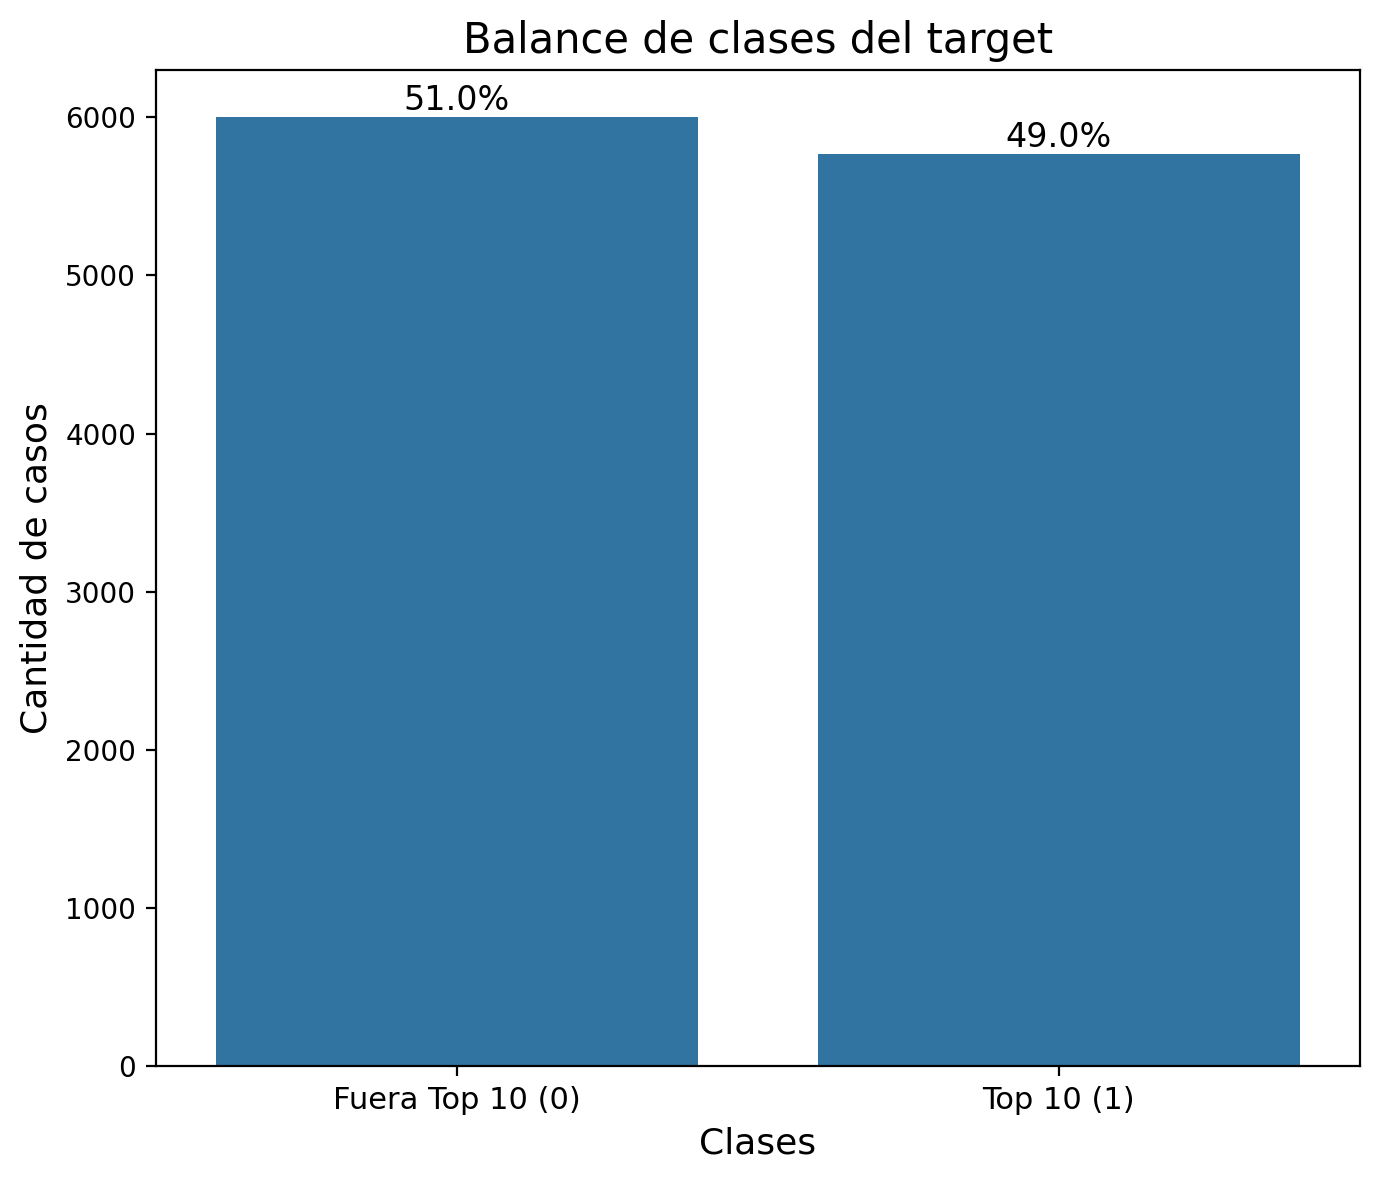

In [ ]:
fig, ax = plt.subplots(figsize=(7,6))
sns.countplot(x="y", data=df, ax=ax)

total = len(df)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.annotate(f"{pct:.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=12)

ax.set_title("Balance de clases del target", fontsize=15)
ax.set_xlabel("Clases", fontsize=13)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Fuera Top 10 (0)", "Top 10 (1)"], fontsize=11)
ax.set_ylabel("Cantidad de casos", fontsize=13)
plt.tight_layout()
plt.show()

El target está prácticamente balanceado (49% / 51%), por lo que no se requieren técnicas de rebalanceo.

## Faltantes por columnas

In [ ]:
cols_interes = ["grid", "position", "positionOrder", "laps", "points", "status"]
faltantes = pd.DataFrame({
    "n_faltantes": df[cols_interes].isna().sum(),
    "pct_faltantes": 100 * df[cols_interes].isna().mean()
}).sort_values("pct_faltantes", ascending=False)

print(faltantes.round(1))

               n_faltantes  pct_faltantes
position              2630           22.4
grid                     0            0.0
positionOrder            0            0.0
laps                     0            0.0
points                   0            0.0
status                   0            0.0


In [ ]:
# Un piloto que terminó (Finished o +N Laps) NO debería tener position NaN
termino = df["status"].str.match(r"^Finished$|^\+\d+ Lap")
print("Filas que terminaron pero tienen position NaN:", (termino & df["position"].isna()).sum())
print("Filas con position NaN:", df["position"].isna().sum())

Filas que terminaron pero tienen position NaN: 15
Filas con position NaN: 2630


In [ ]:
# 15 filas que "terminaron" pero no tienen position
termino = df["status"].str.match(r"^Finished$|^\+\d+ Lap")
sospechosas = df[termino & df["position"].isna()]
print(sospechosas["status"].value_counts())
print()
print(sospechosas[["year","status","positionOrder","laps","y"]].head(15))

status
+11 Laps    3
+9 Laps     2
+10 Laps    2
+1 Lap      1
+17 Laps    1
+12 Laps    1
+2 Laps     1
+26 Laps    1
+42 Laps    1
+14 Laps    1
+8 Laps     1
Name: count, dtype: int64

       year    status  positionOrder  laps  y
949    2006  +11 Laps             10    62  1
1044   2006  +17 Laps             17    41  0
1148   2005    +1 Lap             11    56  0
1151   2005   +2 Laps             14    55  0
1372   2005  +12 Laps             19    55  0
1388   2005  +11 Laps             15    59  0
1470   2005  +26 Laps             17    45  0
20385  2010  +10 Laps             18    46  0
20750  2010   +9 Laps             23    62  0
20790  2011   +9 Laps             15    49  0
20815  2011  +10 Laps             18    46  0
20820  2011  +42 Laps             23    14  0
21076  2011  +14 Laps             16    39  0
21492  2012  +11 Laps             24    58  0
22140  2014   +8 Laps             14    49  0


Conclusiones del análisis de faltantes

Las variables que intervienen en la construcción del target (`positionOrder`, `laps`, `status`) y la feature directa `grid` no presentan valores faltantes y por eso no requieren tratamiento.

La variable `position` presenta ~22% de faltantes. Se trata de faltantes estructurales, no de aleatorios. Corresponden a pilotos que no clasificaron (DNF), donde la ausencia de posición final es un dato. Por esto el target se basa en `positionOrder` que asigna un orden a todos los pilotos.

Al validar la consistencia entre `position` y `status` se detectaron 15 filas de pilotos clasificados a varias vueltas del líder que quedaron sin posición numérica oficial en la fuente. Es una inconsistencia menor de `position` que no afecta al target.

Ese chequeo, sin embargo, expuso un problema sobre la definición del target. El sistema de puntuación cambió a lo largo de la ventana analizada (puntuaban los primeros 6 hasta 2002, los primeros 8 entre 2003 y 2009, y los primeros 10 desde 2010), por lo que la relación "Top 10 = zona de puntos" solo se cumple a partir de 2010. En consecuencia, el target se define como **terminar en el Top 10**.

## Relación `Grid` vs Top 10

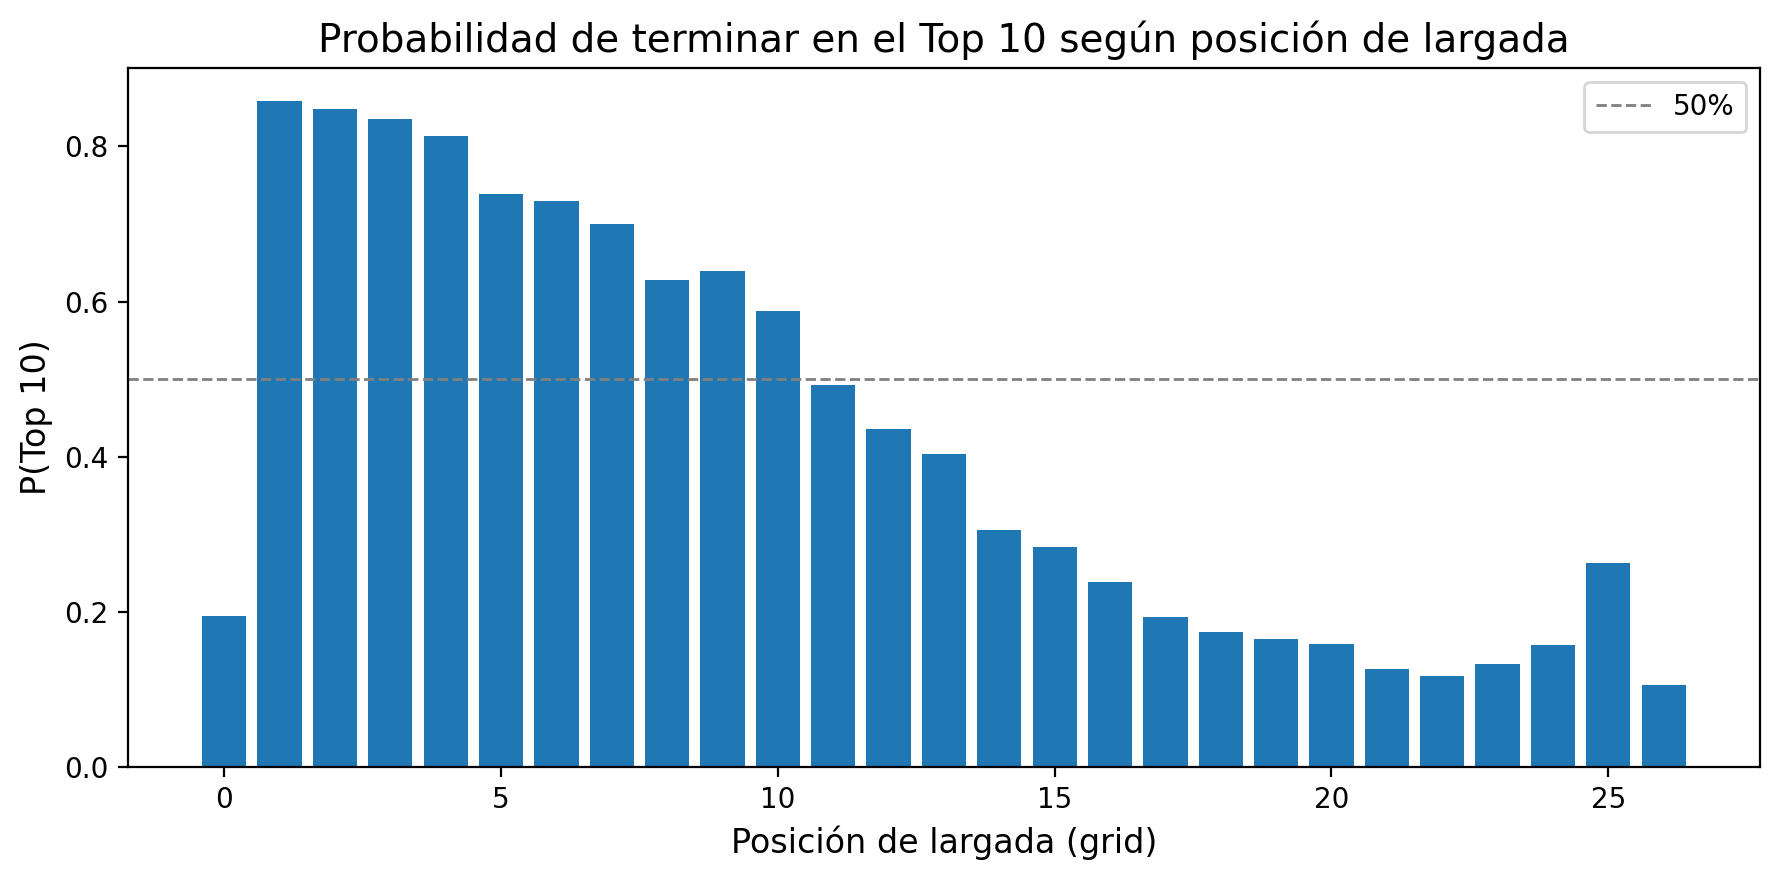

In [ ]:
# Probabilidad de terminar en Top 10 según posición de largada
prob_grid = df.groupby("grid")["y"].mean()

fig, ax = plt.subplots(figsize=(9,4.5))
ax.bar(prob_grid.index, prob_grid.values)

ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="50%")
ax.set_title("Probabilidad de terminar en el Top 10 según posición de largada", fontsize=14)
ax.set_xlabel("Posición de largada (grid)", fontsize=12)
ax.set_ylabel("P(Top 10)", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Repunte de grid =25?
conteo = df.groupby("grid")["y"].agg(["mean","count"])
print(conteo.tail(10))

          mean  count
grid                 
17.0  0.192793    555
18.0  0.173675    547
19.0  0.164486    535
20.0  0.158763    485
21.0  0.125954    262
22.0  0.116981    265
23.0  0.132530     83
24.0  0.156627     83
25.0  0.263158     19
26.0  0.105263     19


La posición de largada muestra una fuerte relación con el target: la probabilidad de Top 10 cae de ~0,85 (primeras posiciones) a ~0,10 (fondo de parrilla), cruzando el 50% alrededor del grid 10-11, lo cual es coherente con el deporte.
La relación no es lineal.
Se identifican dos particularidades:

*   grid = 0 corresponde a largadas desde pit lane y aparece mal ubicado por su codificación numérica —se corrige en preprocesamiento
*   los grids altos (≥23) presentan muy pocos casos, correspondientes a las parrillas ampliadas de 1994-95 (26 autos)

## `Constructor`

In [ ]:
# Cardinalidad y frecuencia de constructor
print("Nº de constructores distintos:", df["constructorId"].nunique())
print()
print("Casos por constructor (top y cola):")
vc = df["constructorId"].value_counts()
print(vc.head(10))
print("...")
print(vc.tail(10))

Nº de constructores distintos: 47

Casos por constructor (top y cola):
constructorId
6      1116
1      1110
3      1109
9       762
15      754
131     599
4       535
5       513
10      401
17      375
Name: count, dtype: int64
...
constructorId
215    46
28     42
30     37
31     35
12     33
23     33
33     30
32     28
13     22
14      8
Name: count, dtype: int64


In [ ]:
# Traer el nombre del constructor
constructors = data["constructors"]
df = df.merge(
    constructors[["constructorId", "name"]].rename(columns={"name": "constructor_name"}),
    on="constructorId", how="left"
)
print(df["constructor_name"].nunique(), "constructores")
print(df["constructor_name"].value_counts().head(10))

47 constructores
constructor_name
Ferrari        1116
McLaren        1110
Williams       1109
Red Bull        762
Sauber          754
Mercedes        599
Renault         535
Toro Rosso      513
Force India     401
Jordan          375
Name: count, dtype: int64


In [ ]:
# Varianza del Top 10 entre `Constructor`

señal_constructor = (df.groupby("constructor_name")["y"]
                       .agg(tasa_top10="mean", n_casos="count")
                       .sort_values("tasa_top10", ascending=False))
print(señal_constructor)

                  tasa_top10  n_casos
constructor_name                     
Brawn               0.969697       33
Mercedes            0.853088      599
Ferrari             0.801971     1116
Red Bull            0.770341      762
BMW Sauber          0.659420      138
McLaren             0.651351     1110
Benetton            0.619048      252
Racing Point        0.567568       74
Renault             0.551402      535
Alpine F1 Team      0.545455      176
Ligier              0.542553       94
Force India         0.526185      401
Lotus F1            0.517241      145
BAR                 0.511211      223
Toyota              0.500000      264
Aston Martin        0.482955      176
Williams            0.429216     1109
Jordan              0.421333      375
Honda               0.405941      101
Jaguar              0.387500      160
Sauber              0.383289      754
AlphaTauri          0.356250      160
Prost               0.339744      156
Larrousse           0.333333       30
Team Lotus  

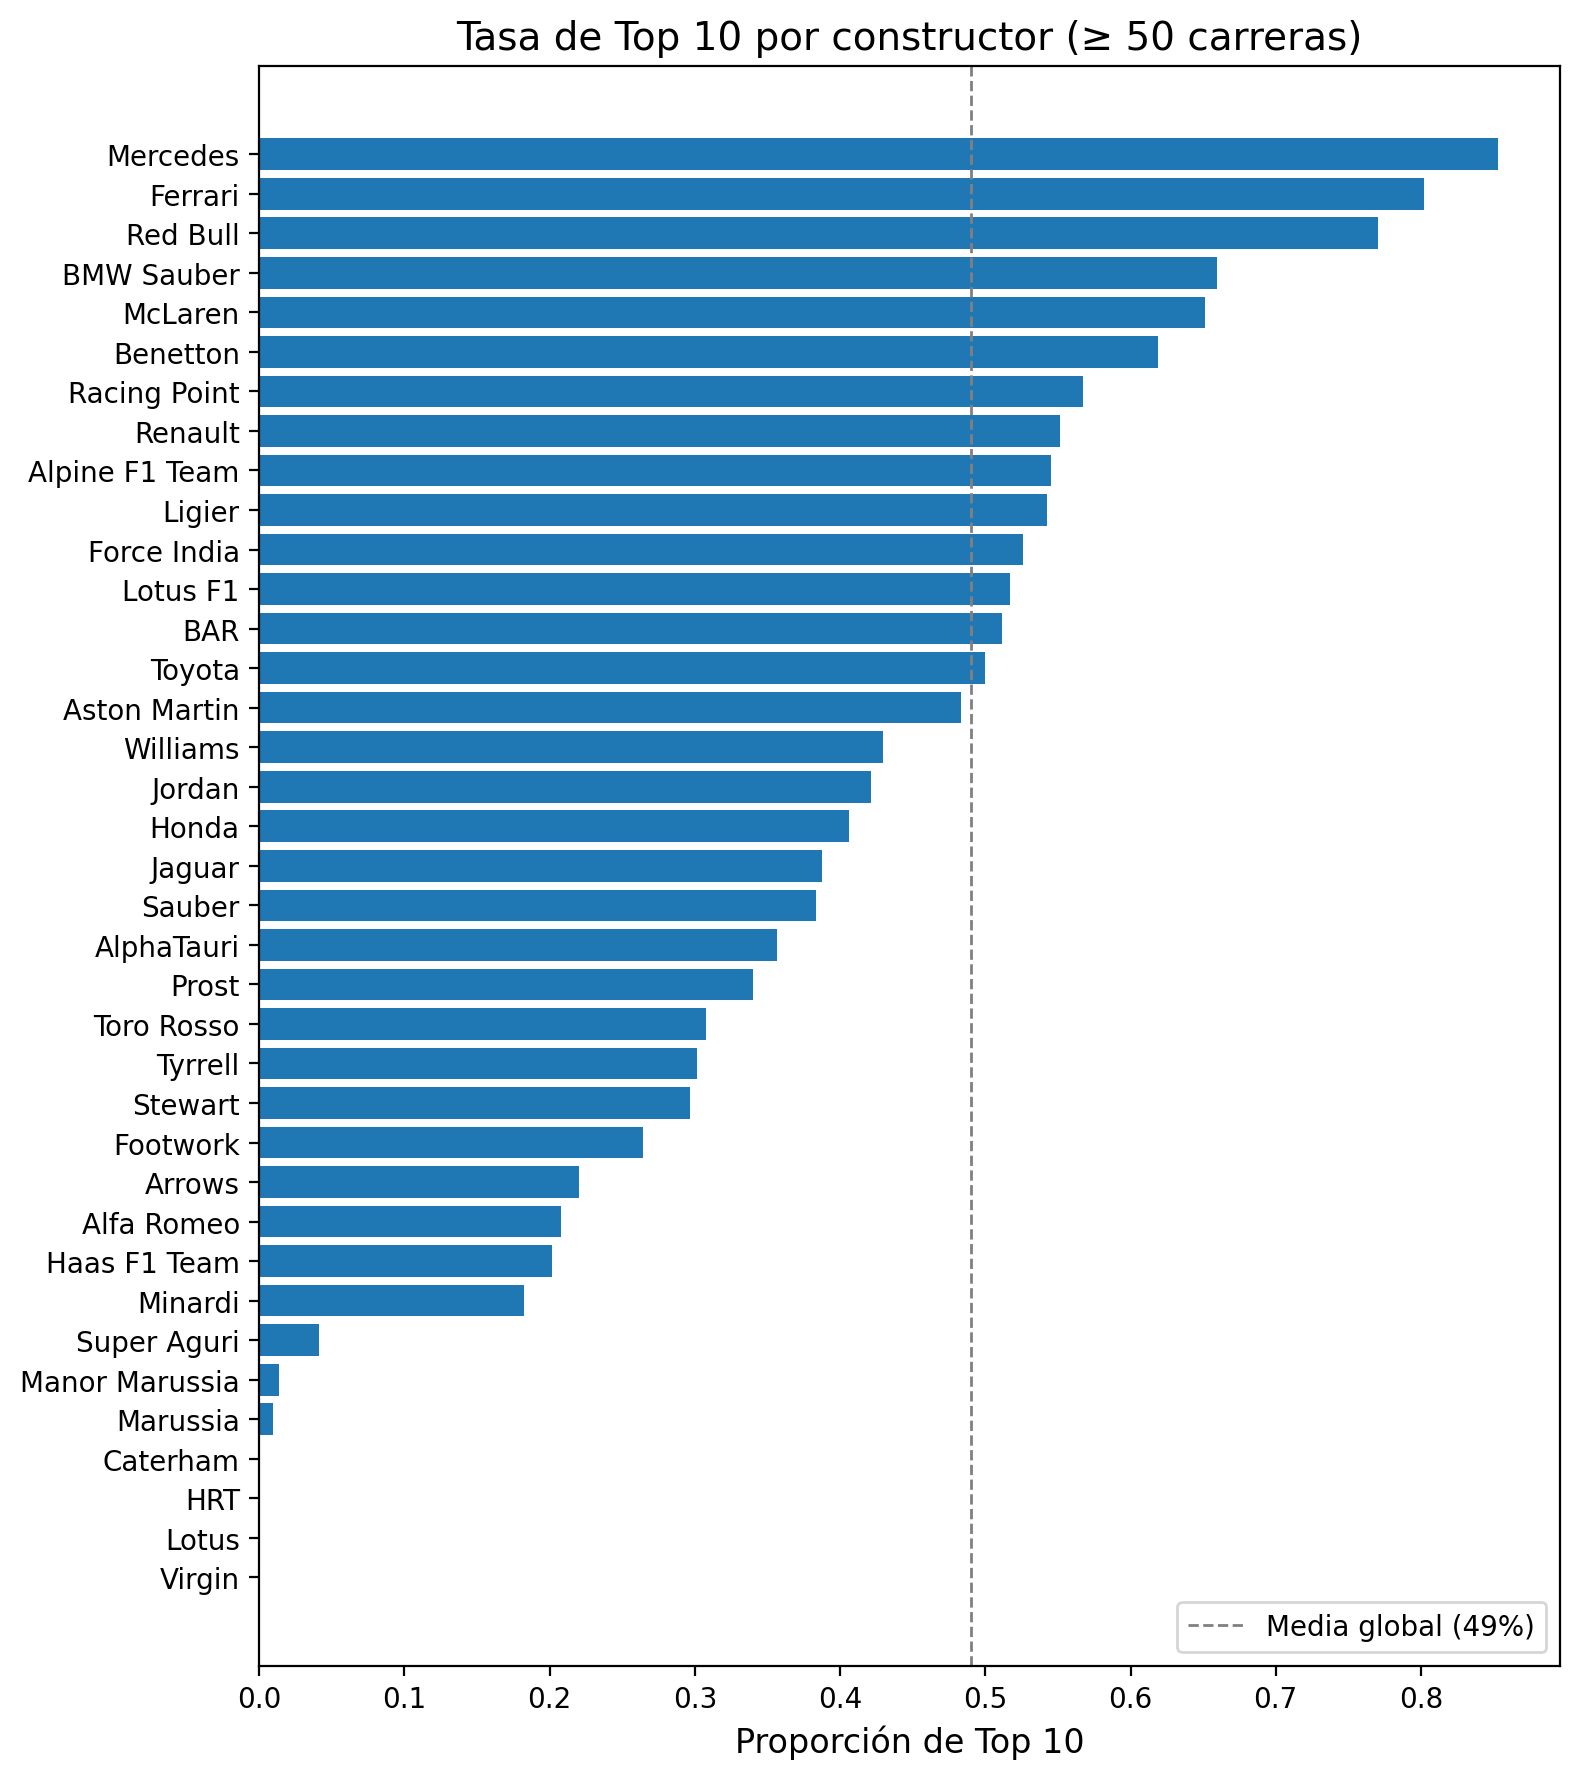

In [ ]:
# Gráfico tasa de Top 10 por constructor, filtrando muestras chicas
UMBRAL = 50
sc = señal_constructor[señal_constructor["n_casos"] >= UMBRAL].sort_values("tasa_top10")

media_global = df["y"].mean()

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(sc.index, sc["tasa_top10"])

ax.axvline(media_global, color="grey", linestyle="--", linewidth=1,
           label=f"Media global ({media_global:.0%})")

ax.set_title(f"Tasa de Top 10 por constructor (≥ {UMBRAL} carreras)", fontsize=14)
ax.set_xlabel("Proporción de Top 10", fontsize=12)
ax.set_ylabel("")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

El `constructor` muestra una señal muy fuerte: la tasa de Top 10 varía entre 0% y ~97% según el equipo. Los equipos históricamente dominantes (Ferrari, Mercedes, Red Bull, McLaren) concentran tasas altas con miles de casos, mientras que equipos de fondo de parrilla (Caterham, HRT, Virgin) registran tasas cercanas a 0.

Los valores extremos con pocos casos (ej. Brawn, 33 carreras; Spyker MF1, 8) son inestables. Se observa además que constructores que son continuaciones unos de otros bajo distinto nombre (p. ej. las sucesivas identidades de la fábrica Jordan/Force India/Racing Point/Aston Martin, o los distintos "Lotus") presentan rendimientos muy dispares, lo que justifica no agruparlos. Dada la alta cardinalidad (47 categorías) y la señal presente, se optará por Target Encoding con smoothing, que regulariza las categorías de pocos casos hacia la media global.

## `Circuito`

In [ ]:
# Nombre del circuito
circuits = data["circuits"]
df = df.merge(
    circuits[["circuitId", "name"]].rename(columns={"name": "circuit_name"}),
    on="circuitId", how="left"
)

# Señal de circuito
señal_circuito = (df.groupby("circuit_name")["y"]
                    .agg(tasa_top10="mean", n_casos="count")
                    .sort_values("tasa_top10", ascending=False))
print("Nº de circuitos:", df["circuit_name"].nunique())
print(señal_circuito)

Nº de circuitos: 43
                                      tasa_top10  n_casos
circuit_name                                             
Autodromo Internazionale del Mugello    0.555556       18
Indianapolis Motor Speedway             0.546763      139
Losail International Circuit            0.535714       56
Sochi Autodrom                          0.526316      152
Albert Park Grand Prix Circuit          0.518304      519
Circuit Paul Ricard                     0.512821       78
Jeddah Corniche Circuit                 0.512821       78
Autódromo Hermanos Rodríguez            0.508475      177
Circuit de Spa-Francorchamps            0.502600      577
Autódromo Internacional do Algarve      0.500000       40
Circuit Park Zandvoort                  0.500000       80
Las Vegas Strip Street Circuit          0.500000       40
Circuit of the Americas                 0.500000      240
Miami International Autodrome           0.500000       60
Baku City Circuit                       0.500000    

A diferencia de constructor, el circuito no muestra señal marginal sobre el target: descartando los circuitos con pocas carreras, las tasas de Top 10 se concentran entre 0,42 y 0,55, en torno a la media global (0,49). Los circuitos con más casos (Silverstone, Barcelona, Monza, Mónaco) prácticamente coinciden con el promedio.

Una posible interacción `circuito` × `constructor` (un equipo puede rendir distinto según las características de cada trazado) queda planteada como trabajo futuro.

# 4. Feature Engineering

## Puntos del piloto normalizados

In [ ]:
# Asegurar que points es numérico
df["points"] = pd.to_numeric(df["points"], errors="coerce").fillna(0)

# Ordenar por temporada-piloto-fecha (imprescindible para el acumulado)
df = df.sort_values(["year", "driverId", "round"])

# 1) Puntos acumulados ANTES de la carrera actual (sin leakage)
df["pts_piloto_prev"] = (
    df.groupby(["year", "driverId"])["points"].cumsum() - df["points"]
)

# 2) Normalización por temporada: puntos del piloto / puntos del líder en esa carrera
pts_lider = df.groupby("raceId")["pts_piloto_prev"].transform("max")
df["pts_piloto_norm"] = (df["pts_piloto_prev"] / pts_lider
                         ).replace([np.inf, -np.inf], np.nan).fillna(0)

# 3) Validación
print("Nulos:", df["pts_piloto_norm"].isna().sum())
print("Rango:", df["pts_piloto_norm"].min(), "a", df["pts_piloto_norm"].max())
print("Round 1 (máx, debe ser 0):", df[df["round"] == 1]["pts_piloto_norm"].max())

Nulos: 0
Rango: 0.0 a 1.0
Round 1 (máx, debe ser 0): 0.0


La fuerza del piloto (pts_piloto_norm) se construye en dos pasos.

Primero, los puntos acumulados del piloto en el campeonato antes de cada carrera (cumsum de puntos menos los de la carrera actual), calculados sobre la serie completa para preservar la secuencia de rounds y evitar leakage temporal.


Segundo, se normalizan dividiéndolos por los puntos del líder del campeonato en esa misma carrera, obteniendo un valor entre 0 (sin puntos) y 1 (líder). La normalización hace la variable comparable entre eras pese a los cambios en el sistema de puntuación, y conserva la magnitud relativa de la ventaja (un dominador queda cerca de 1, una pelea pareja reparte valores intermedios). Se validó que en la primera carrera de cada temporada la variable vale 0 para todos (ausencia de historia previa) y que su rango es [0, 1].

## Puntos del constructor normalizados

In [ ]:
df["points"] = pd.to_numeric(df["points"], errors="coerce").fillna(0)

# 1) Agregar a grano constructor-carrera: puntos del equipo (suma de sus autos) por carrera
cc = (df.groupby(["raceId", "constructorId", "year", "round"], as_index=False)["points"]
        .sum())

# 2) Acumulado del equipo ANTES de la carrera actual (sin leakage)
cc = cc.sort_values(["year", "constructorId", "round"])
cc["pts_constructor_prev"] = (
    cc.groupby(["year", "constructorId"])["points"].cumsum() - cc["points"]
)

# 3) Traer de vuelta a df (nivel piloto-carrera); ambos pilotos del equipo comparten el valor
df = df.merge(
    cc[["raceId", "constructorId", "pts_constructor_prev"]],
    on=["raceId", "constructorId"], how="left"
)

# 4) Normalización por temporada: puntos del equipo / puntos del equipo líder en esa carrera
pts_lider_c = df.groupby("raceId")["pts_constructor_prev"].transform("max")
df["pts_constructor_norm"] = (df["pts_constructor_prev"] / pts_lider_c
                              ).replace([np.inf, -np.inf], np.nan).fillna(0)

# 5) Validación
print("Nulos:", df["pts_constructor_norm"].isna().sum())
print("Rango:", df["pts_constructor_norm"].min(), "a", df["pts_constructor_norm"].max())
print("Round 1 (máx, debe ser 0):", df[df["round"] == 1]["pts_constructor_norm"].max())

Nulos: 0
Rango: 0.0 a 1.0
Round 1 (máx, debe ser 0): 0.0


La fuerza del constructor (pts_constructor_norm) es análoga a la del piloto: primero se suman los puntos de los dos autos del equipo en cada carrera, luego se calcula el acumulado previo (cumsum menos la carrera actual) y se normaliza por los puntos del equipo líder. El paso de agregación es necesario porque cada constructor tiene dos filas por carrera (una por piloto); calcularlo directamente a nivel piloto filtraría los puntos del compañero de equipo de la carrera actual. Ambos pilotos de un mismo equipo comparten el valor, que representa la fuerza del equipo antes de esa carrera.

## Experiencia del piloto

In [ ]:
# Historia completa de carreras por piloto (sin filtros de ventana ni resultado)
hist = (data["results"][["raceId", "driverId"]]
        .merge(data["races"][["raceId", "year", "round"]], on="raceId"))
hist = hist.sort_values(["driverId", "year", "round"])

# cumcount = nº de carreras PREVIAS (arranca en 0 para el debut -> sin leakage)
hist["experiencia"] = hist.groupby("driverId").cumcount()

# Traer a df por la clave piloto-carrera
df = df.merge(
    hist[["raceId", "driverId", "experiencia"]],
    on=["raceId", "driverId"], how="left"
)

# Validación
print("Nulos:", df["experiencia"].isna().sum())
print("Rango:", df["experiencia"].min(), "a", df["experiencia"].max())
print("Debut (experiencia mínima, debe ser 0):", df["experiencia"].min())

Nulos: 0
Rango: 0 a 403
Debut (experiencia mínima, debe ser 0): 0


Experiencia del piloto (experiencia). Número de carreras que el piloto disputó antes de la carrera actual. A diferencia de los puntos, la experiencia no se reinicia por temporada. Se cuenta sobre la historia completa del dataset (todas las temporadas, incluidas las carreras con abandono), ya que un piloto gana experiencia independientemente del resultado. Un debutante entra con experiencia 0.

## Gap al poleman en clasificación

In [ ]:
qualy = data["qualifying"].copy()

# Parseo de "M:SS.mmm" a segundos
def a_segundos(t):
    if pd.isna(t):
        return np.nan
    m, s = str(t).split(":")
    return int(m) * 60 + float(s)

for c in ["q1", "q2", "q3"]:
    qualy[c + "_s"] = qualy[c].apply(a_segundos)

# Mejor tiempo del piloto = mínimo entre sus 3 segmentos (maneja los nulos estructurales)
qualy["mejor_tiempo"] = qualy[["q1_s", "q2_s", "q3_s"]].min(axis=1)

# Tiempo de la pole = mejor tiempo absoluto de esa clasificación
qualy["pole_tiempo"] = qualy.groupby("raceId")["mejor_tiempo"].transform("min")

# Gap porcentual (comparable entre circuitos y eras)
qualy["gap_pct"] = 100 * (qualy["mejor_tiempo"] - qualy["pole_tiempo"]) / qualy["pole_tiempo"]

# Merge a df
df = df.merge(
    qualy[["raceId", "driverId", "gap_pct"]],
    on=["raceId", "driverId"], how="left"
)

# Diagnóstico (NO imputamos acá; eso va en preprocesamiento)
print("Nulos en gap_pct:", df["gap_pct"].isna().sum(),
      f"({100*df['gap_pct'].isna().mean():.1f}%)")
print("gap_pct — min:", round(df["gap_pct"].min(), 2),
      "mediana:", round(df["gap_pct"].median(), 2),
      "max:", round(df["gap_pct"].max(), 1), "<- outlier a tratar")

Nulos en gap_pct: 1858 (15.8%)
gap_pct — min: 0.0 mediana: 1.82 max: 922.9 <- outlier a tratar


Gap a la pole (gap_pct). Diferencia porcentual entre el mejor tiempo de clasificación del piloto y el tiempo de la pole en esa misma sesión. Se toma el mínimo de los tres segmentos (Q1/Q2/Q3) como mejor tiempo del piloto, lo que maneja naturalmente los nulos estructurales (un piloto eliminado en Q1 no tiene tiempos de Q2/Q3). Se expresa en porcentaje y no en segundos para que sea comparable entre circuitos de distinta duración. Los tiempos de clasificación son previos a la carrera, por lo que no introducen leakage. Se detectan dos cuestiones a resolver en preprocesamiento: ~16% de filas sin tiempo de quali válido (a imputar) y valores atípicos extremos por datos mal cargados (a acotar).

## Matriz de correlación de features

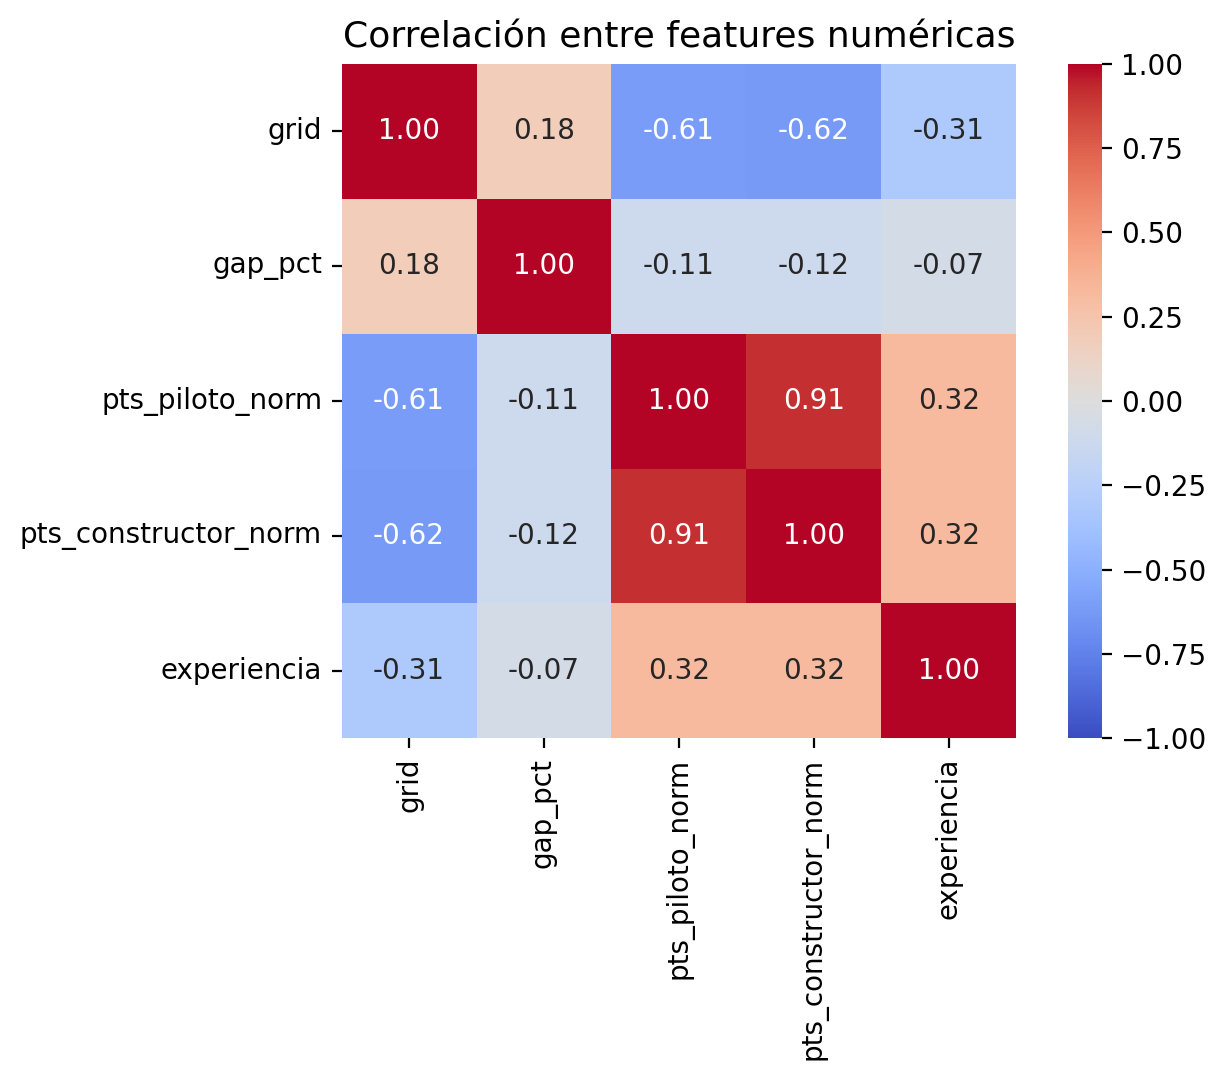

                      grid  gap_pct  pts_piloto_norm  pts_constructor_norm  \
grid                  1.00     0.18            -0.61                 -0.62   
gap_pct               0.18     1.00            -0.11                 -0.12   
pts_piloto_norm      -0.61    -0.11             1.00                  0.91   
pts_constructor_norm -0.62    -0.12             0.91                  1.00   
experiencia          -0.31    -0.07             0.32                  0.32   

                      experiencia  
grid                        -0.31  
gap_pct                     -0.07  
pts_piloto_norm              0.32  
pts_constructor_norm         0.32  
experiencia                  1.00  


In [ ]:
# Correlación entre features numéricas
num_features = ["grid", "gap_pct", "pts_piloto_norm", "pts_constructor_norm", "experiencia"]

corr = df[num_features].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlación entre features numéricas", fontsize=13)
plt.tight_layout()
plt.show()
print(corr.round(2))

In [ ]:
print(df[num_features].corr(method="spearman").round(2))

                      grid  gap_pct  pts_piloto_norm  pts_constructor_norm  \
grid                  1.00     0.84            -0.65                 -0.66   
gap_pct               0.84     1.00            -0.66                 -0.67   
pts_piloto_norm      -0.65    -0.66             1.00                  0.91   
pts_constructor_norm -0.66    -0.67             0.91                  1.00   
experiencia          -0.38    -0.38             0.43                  0.38   

                      experiencia  
grid                        -0.38  
gap_pct                     -0.38  
pts_piloto_norm              0.43  
pts_constructor_norm         0.38  
experiencia                  1.00  


Las features de puntos presentan correlación moderada con `grid` (−0,61 y −0,62): pilotos y equipos con más puntos acumulados tienden a largar más adelante. No son redundantes: `grid` captura el rendimiento en esa carrera puntual, mientras que los puntos resumen el rendimiento previo en la temporada.

La relación más fuerte se da entre `pts_piloto_norm` y `pts_constructor_norm` (0,91), y tiene una explicación mecánica: los puntos del constructor son la suma de los puntos de sus dos pilotos, por lo que una variable contiene en gran parte a la otra. Mantener ambas aporta poca información adicional y en la regresión logística, la multicolinealidad vuelve inestables los coeficientes y dificulta su interpretación. Se conserva `pts_constructor_norm`, porque en F1 el rendimiento del auto es el factor dominante y la variable es más estable (se basa en dos autos en lugar de uno). La capacidad individual del piloto queda representada por el encoding de `driverId`. Se descarta `pts_piloto_norm`.

`experiencia` se correlaciona de forma moderada con los puntos (0,32) y con `grid` (−0,31). Los pilotos con más carreras tienden a estar en mejores equipos, en parte por un sesgo de supervivencia: los que rinden permanecen más tiempo en la categoría. La relación no es tan fuerte como para considerarla redundante.

La correlación de Pearson entre `gap_pct` y `grid` (0,18) es menor a la esperable, dado que la grilla surge de la clasificación. Con Spearman, que es robusta a valores extremos, asciende a 0,84, lo que indica que el valor de Pearson está distorsionado por los outliers de `gap_pct` (máximo de 922%), tratados luego en el preprocesamiento.


# 5. Preprocesamiento de datos

## % de gap a pole

In [ ]:
falta = df["gap_pct"].isna()

# Comparar tasa de Top 10 con y sin gap
print(df.groupby(falta)["y"].agg(["mean", "count"]))

# ¿Se concentra en ciertos años?
print(falta.groupby(df["year"]).mean().round(2))

# ¿Dónde largan los que no tienen gap?
print(df.loc[falta, "grid"].describe())

# Outliers: ¿son pilotos puntuales o carreras enteras con gaps inflados?
print(df.nlargest(15, "gap_pct")[["year", "raceId", "driverId", "grid", "gap_pct"]])

# Chequeo de granularidad: ¿qualifying tiene una sola fila por piloto-carrera?
print("Duplicados en qualy:", qualy.duplicated(["raceId", "driverId"]).sum())

             mean  count
gap_pct                 
False    0.492329   9908
True     0.477395   1858
year
1994    0.05
1995    0.06
1996    0.57
1997    0.42
1998    0.58
1999    0.82
2000    0.75
2001    0.94
2002    0.88
2003    0.03
2004    0.06
2005    0.05
2006    0.02
2007    0.01
2008    0.01
2009    0.00
2010    0.01
2011    0.02
2012    0.01
2013    0.00
2014    0.02
2015    0.01
2016    0.02
2017    0.01
2018    0.01
2019    0.03
2020    0.00
2021    0.02
2022    0.01
2023    0.01
2024    0.01
Name: gap_pct, dtype: float64
count    1858.000000
mean       11.887513
std         6.525436
min         0.000000
25%         6.000000
50%        12.000000
75%        18.000000
max        24.000000
Name: grid, dtype: float64
       year  raceId  driverId  grid     gap_pct
684    1995     255        87  23.0  922.861981
11277  2023    1099       858  20.0   45.595649
8480   2016     958       837  21.0   37.796536
8462   2016     958       836  20.0   34.237479
8358   2016     958       8

In [ ]:
# Elección de corte
for tope in [7, 10, 15]:
    print(tope, (df["gap_pct"] > tope).sum())

print(df.loc[df["gap_pct"] > 7, "y"].agg(["mean", "count"]))

7 366
10 136
15 76
mean       0.117486
count    366.000000
Name: y, dtype: float64


*Tratamiento de `gap_pct`*

Faltantes (15,8%): La tasa de Top 10 es prácticamente igual con y sin gap (47,7% vs 49,2%), y los casos sin gap se distribuyen por toda la grilla, por lo que el faltante no depende del rendimiento del piloto. Se concentra en 1996–2002, lo que indica un hueco de cobertura de la fuente. Se imputa con la mediana dentro del pipeline, ajustada solo sobre train. Como limitación, en 1996–2002 la variable aporta poca información y el peso recae en `grid`.

Valores extremos: Se detectaron dos tipos: un error de carga (922% en 1995) y gaps reales pero no representativos del ritmo (20–45%), asociados a problemas en clasificación o condiciones cambiantes durante la sesión. Se aplica un tope en 7%, basado en la regla del 107% del reglamento deportivo. Afecta a 366 filas (3,1%), cuya tasa de Top 10 es 11,7%, similar a la del fondo de la grilla.

## Pasos antes del split

In [ ]:
# 1) Tope de gap_pct por regla del 107% (los NaN se mantienen como NaN)
df["gap_pct"] = df["gap_pct"].clip(upper=7)

# 2) grid = 0 (largada desde pit lane) -> última posición de la parrilla de esa carrera + 1
n_pitlane = (df["grid"] == 0).sum()
print(f"Filas con grid = 0 antes del reemplazo: {n_pitlane}")

# Última posición de parrilla en cada carrera (el max ignora los 0)
ultima_pos = df.groupby("raceId")["grid"].transform("max")

df["grid"] = np.where(df["grid"] == 0, ultima_pos + 1, df["grid"])

# Validación
print(f"Filas con grid = 0 después del reemplazo: {(df['grid'] == 0).sum()}")
print(f"Rango de grid: {df['grid'].min():.0f} a {df['grid'].max():.0f}")


# 3) Orden cronológico (imprescindible para el split temporal)
df = df.sort_values(["year", "round"]).reset_index(drop=True)

Filas con grid = 0 antes del reemplazo: 72
Filas con grid = 0 después del reemplazo: 0
Rango de grid: 1 a 26


Largadas desde pit lane: Las 72 filas con `grid = 0` (0,6%) corresponden a largadas desde pit lane, no a la primera posición. Se reemplazan por la última posición de largada de esa carrera + 1, lo que las ubica detrás de toda la parrilla.

El tope de gap_pct y el reemplazo de grid = 0 son reglas determinísticas que no estiman parámetros a partir de los datos, por lo que se aplican antes del split sin generar leakage.

## Split de datos

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

FEATURES = ["grid", "gap_pct", "experiencia", "pts_constructor_norm",
            "driverId", "constructorId"]

df[["driverId", "constructorId"]] = df[["driverId", "constructorId"]].astype(str)

train = df[df["year"] <= 2020]
test  = df[df["year"] >= 2021]

X_train, y_train = train[FEATURES], train["y"]
X_test,  y_test  = test[FEATURES],  test["y"]

print(f"Train: {len(train):,} filas ({train.year.min()}–{train.year.max()}) | "
      f"Top10: {y_train.mean():.1%}")
print(f"Test:  {len(test):,} filas ({test.year.min()}–{test.year.max()}) | "
      f"Top10: {y_test.mean():.1%}")

tscv = TimeSeriesSplit(n_splits=5)

Train: 10,020 filas (1994–2020) | Top10: 48.6%
Test:  1,746 filas (2021–2024) | Top10: 51.5%


*Estrategia de validación*

Se usa un split temporal: entrenamiento con 1994–2020 (10.020 filas) y test con 2021–2024 (1.746 filas, ~15%). Dentro de entrenamiento, la validación cruzada usa `TimeSeriesSplit` (5 folds), donde cada fold entrena con temporadas anteriores y valida con las siguientes.

Un split aleatorio generaría dos problemas. Primero, leakage temporal: el Target Encoding de pilotos y constructores se calcularía con temporadas futuras (por ejemplo, codificar a un piloto en 2008 usando su rendimiento de 2015). Segundo, dependencia entre filas: en cada carrera hay exactamente 10 pilotos en el Top 10, por lo que repartir pilotos de una misma carrera entre train y test no es independiente. El split temporal resuelve ambos, ya que cada carrera queda completa de un solo lado.

La diferencia de balance entre train (48,6%) y test (51,5%) es estructural: la tasa de Top 10 equivale a 10 dividido la cantidad de pilotos que largan, que era mayor en los años 90 (hasta 26 autos) que en la actualidad (20).

## Preprocesamiento

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score

NUM = ["grid", "gap_pct", "experiencia", "pts_constructor_norm"]
CAT = ["driverId", "constructorId"]

def construir_preprocesador():
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("te", TargetEncoder(target_type="binary", smooth="auto",
                             random_state=RANDOM_STATE)),
        ("scaler", StandardScaler()),
    ])
    return ColumnTransformer([
        ("num", num_pipe, NUM),
        ("cat", cat_pipe, CAT),
    ])


*Construcción del preprocesador*

Las transformaciones que estiman parámetros a partir de los datos se aplican dentro de un `Pipeline`, de modo que en cada fold de validación se ajustan solo con los datos de entrenamiento:

- *Variables numéricas* (`grid`, `gap_pct`, `experiencia`, `pts_constructor_norm`): imputación por mediana, robusta a valores extremos, seguida de estandarización (`StandardScaler`), necesaria para la regresión logística.
- *Variables categóricas* (`driverId`, `constructorId`): Target Encoding con smoothing. Se eligió en lugar de One-Hot por su alta cardinalidad (47 constructores y más de 100 pilotos). El smoothing regulariza las categorías con pocos casos hacia la media global, y las categorías no vistas en entrenamiento (por ejemplo, pilotos debutantes) reciben la media global. Durante el entrenamiento, el encoder aplica validación cruzada interna para que cada fila no se codifique con su propio target.

Ajustar el Target Encoding fuera del pipeline, sobre todo el dataset, filtraría información del target hacia las métricas de validación.

# 6. Modelo de Machine Learning

## Regresión logística y relación con 'grid'

In [ ]:
# Baseline de dominio: -grid como score, evaluado en los mismos folds
auc_grid = []
for idx_tr, idx_val in tscv.split(X_train):
    auc_grid.append(roc_auc_score(y_train.iloc[idx_val], -X_train["grid"].iloc[idx_val]))

# Baseline de modelo: regresión logística
modelo_lr = Pipeline([
    ("prep", construir_preprocesador()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
auc_lr = cross_val_score(modelo_lr, X_train, y_train, cv=tscv, scoring="roc_auc")

# --- Comparación fold por fold ---
for i, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    años = X_train.index[val_idx]
    print(f"Fold {i+1} | val {train.loc[años, 'year'].min()}–{train.loc[años, 'year'].max()} | "
          f"AUC grid: {auc_grid[i]:.3f} | AUC logística: {auc_lr[i]:.3f}")

print(f"\nMedia  | AUC grid: {np.mean(auc_grid):.3f} ± {np.std(auc_grid):.3f} | "
      f"AUC logística: {auc_lr.mean():.3f} ± {auc_lr.std():.3f}")

Fold 1 | val 1998–2003 | AUC grid: 0.734 | AUC logística: 0.732
Fold 2 | val 2003–2008 | AUC grid: 0.782 | AUC logística: 0.800
Fold 3 | val 2008–2012 | AUC grid: 0.835 | AUC logística: 0.817
Fold 4 | val 2012–2016 | AUC grid: 0.853 | AUC logística: 0.855
Fold 5 | val 2016–2020 | AUC grid: 0.826 | AUC logística: 0.826

Media  | AUC grid: 0.806 ± 0.043 | AUC logística: 0.806 ± 0.041


In [ ]:
# Dependencia de grid
modelo_lr.fit(X_train, y_train)
nombres = modelo_lr.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(modelo_lr.named_steps["clf"].coef_[0], index=nombres)
print(coefs.sort_values(key=abs, ascending=False).round(3))

num__grid                   -0.615
cat__driverId                0.350
cat__constructorId           0.272
num__pts_constructor_norm    0.248
num__gap_pct                -0.167
num__experiencia            -0.039
dtype: float64


In [ ]:
# Prueba sin grid
NUM_SIN_GRID = ["gap_pct", "experiencia", "pts_constructor_norm"]
prep_sin_grid = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), NUM_SIN_GRID),
    ("cat", Pipeline([("te", TargetEncoder(target_type="binary", smooth="auto",
                                           random_state=RANDOM_STATE)),
                      ("scaler", StandardScaler())]), CAT),
])
modelo_sin_grid = Pipeline([("prep", prep_sin_grid),
                            ("clf", LogisticRegression(max_iter=1000))])
auc_sin_grid = cross_val_score(modelo_sin_grid, X_train, y_train,
                               cv=tscv, scoring="roc_auc")
print(f"AUC sin grid: {auc_sin_grid.mean():.3f} ± {auc_sin_grid.std():.3f}")

AUC sin grid: 0.773 ± 0.038


*Baseline y aporte de las features*

La regresión logística obtiene un AUC medio de 0,806 en validación temporal, idéntico al de la regla simple "Top 10 si larga entre los 10 primeros" (0,806). Con las features disponibles, un modelo lineal no mejora la capacidad de ordenar pilotos respecto de la posición de largada.

Los coeficientes tienen los signos esperados y las variables históricas (encodings de piloto y constructor, puntos del constructor) reciben peso no nulo. Sin embargo, al estar correlacionadas con `grid`, modifican la magnitud de las probabilidades pero casi no alteran el orden entre pilotos, que es lo que mide el AUC.

Un modelo sin `grid` alcanza un AUC de 0,773, es decir, recupera cerca del 89% del poder de discriminación por encima del azar. Las demás features no carecen de información, sino que son mayormente redundantes con la posición de largada, que ya resume la competitividad del auto y del piloto en ese fin de semana.

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = Pipeline([
    ("prep", construir_preprocesador()),
    ("clf", RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                   random_state=RANDOM_STATE)),
])
auc_rf = cross_val_score(modelo_rf, X_train, y_train, cv=tscv, scoring="roc_auc")

for i in range(len(auc_rf)):
    print(f"Fold {i+1} | grid: {auc_grid[i]:.3f} | LR: {auc_lr[i]:.3f} | RF: {auc_rf[i]:.3f}")
print(f"\nMedia RF: {auc_rf.mean():.3f} ± {auc_rf.std():.3f}")

Fold 1 | grid: 0.734 | LR: 0.732 | RF: 0.693
Fold 2 | grid: 0.782 | LR: 0.800 | RF: 0.749
Fold 3 | grid: 0.835 | LR: 0.817 | RF: 0.791
Fold 4 | grid: 0.853 | LR: 0.855 | RF: 0.824
Fold 5 | grid: 0.826 | LR: 0.826 | RF: 0.820

Media RF: 0.775 ± 0.049


In [ ]:
# Validación Random Forest
from sklearn.model_selection import cross_validate

res_rf = cross_validate(modelo_rf, X_train, y_train, cv=tscv,
                        scoring="roc_auc", return_train_score=True)
print("AUC train:", res_rf["train_score"].round(3))
print("AUC val:  ", res_rf["test_score"].round(3))

AUC train: [0.967 0.962 0.976 0.979 0.986]
AUC val:   [0.693 0.749 0.791 0.824 0.82 ]


El Random Forest con hiperparámetros por defecto presenta un AUC de ~0,97 en entrenamiento frente a ~0,78 en validación, lo que evidencia sobreajuste: los árboles sin restricciones memorizan el ruido del target (abandonos, incidentes), que no es predecible con información previa a la carrera.

## Hiperparámetros de Random Forest

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    "clf__min_samples_leaf": [20, 50, 100],
    "clf__max_depth": [4, 8, None],
}

modelo_rf = Pipeline([
    ("prep", construir_preprocesador()),
    ("clf", RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                   random_state=RANDOM_STATE)),
])

gs_rf = GridSearchCV(modelo_rf, param_grid_rf, cv=tscv, scoring="roc_auc",
                     return_train_score=True, n_jobs=-1)
gs_rf.fit(X_train, y_train)

resultados = pd.DataFrame(gs_rf.cv_results_)[
    ["param_clf__min_samples_leaf", "param_clf__max_depth",
     "mean_train_score", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)
print(resultados.round(3))
print("\nMejores parámetros:", gs_rf.best_params_)

   param_clf__min_samples_leaf param_clf__max_depth  mean_train_score  \
5                          100                    8             0.777   
8                          100                 None             0.777   
1                           50                    4             0.775   
2                          100                    4             0.773   
0                           20                    4             0.778   
4                           50                    8             0.788   
7                           50                 None             0.789   
3                           20                    8             0.806   
6                           20                 None             0.817   

   mean_test_score  std_test_score  
5            0.816           0.044  
8            0.816           0.044  
1            0.816           0.043  
2            0.816           0.044  
0            0.815           0.043  
4            0.815           0.044  
7         

In [ ]:
# Random Forest vs grid

mask = (resultados["param_clf__max_depth"] == 4) & (resultados["param_clf__min_samples_leaf"] == 50)
best = resultados.index[mask][0]
auc_rf_tuned = [gs_rf.cv_results_[f"split{i}_test_score"][best] for i in range(5)]

for i in range(5):
    dif = auc_rf_tuned[i] - auc_grid[i]
    print(f"Fold {i+1} | grid: {auc_grid[i]:.3f} | LR: {auc_lr[i]:.3f} | "
          f"RF: {auc_rf_tuned[i]:.3f} | RF − grid: {dif:+.3f}")

Fold 1 | grid: 0.734 | LR: 0.732 | RF: 0.737 | RF − grid: +0.003
Fold 2 | grid: 0.782 | LR: 0.800 | RF: 0.804 | RF − grid: +0.022
Fold 3 | grid: 0.835 | LR: 0.817 | RF: 0.834 | RF − grid: -0.000
Fold 4 | grid: 0.853 | LR: 0.855 | RF: 0.862 | RF − grid: +0.008
Fold 5 | grid: 0.826 | LR: 0.826 | RF: 0.841 | RF − grid: +0.015


## Hiperparámetros en Regresión Logística


In [ ]:
param_grid_lr = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
}

modelo_lr = Pipeline([
    ("prep", construir_preprocesador()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

gs_lr = GridSearchCV(modelo_lr, param_grid_lr, cv=tscv, scoring="roc_auc",
                     return_train_score=True, n_jobs=-1)
gs_lr.fit(X_train, y_train)

resultados_lr = pd.DataFrame(gs_lr.cv_results_)[
    ["param_clf__C", "mean_train_score", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)
print(resultados_lr.round(3))
print("\nMejor C:", gs_lr.best_params_)

# Comparación pareada contra grid y RF, con el mejor C
best_lr = gs_lr.best_index_
auc_lr_tuned = [gs_lr.cv_results_[f"split{i}_test_score"][best_lr] for i in range(5)]
for i in range(5):
    print(f"Fold {i+1} | grid: {auc_grid[i]:.3f} | LR tuned: {auc_lr_tuned[i]:.3f} | "
          f"RF: {auc_rf_tuned[i]:.3f}")

   param_clf__C  mean_train_score  mean_test_score  std_test_score
1         0.010             0.765            0.808           0.040
0         0.001             0.763            0.806           0.037
2         0.100             0.765            0.806           0.041
3         1.000             0.765            0.806           0.041
4        10.000             0.765            0.806           0.041
5       100.000             0.765            0.806           0.041

Mejor C: {'clf__C': 0.01}
Fold 1 | grid: 0.734 | LR tuned: 0.735 | RF: 0.737
Fold 2 | grid: 0.782 | LR tuned: 0.804 | RF: 0.804
Fold 3 | grid: 0.835 | LR tuned: 0.819 | RF: 0.834
Fold 4 | grid: 0.853 | LR tuned: 0.854 | RF: 0.862
Fold 5 | grid: 0.826 | LR tuned: 0.825 | RF: 0.841


## **Selección del modelo**

Se compararon tres enfoques mediante validación cruzada temporal (`TimeSeriesSplit`, 5 folds sobre 1994–2020), usando AUC como métrica principal:

| Modelo | AUC validación (media ± desvío) |
|---|---|
| Regla simple: Top 10 si larga entre los 10 primeros | 0,806 ± 0,043 |
| Regresión logística (C = 1, por defecto) | 0,806 ± 0,041 |
| Regresión logística optimizada (C = 0,01) | 0,808 ± 0,040 |
| Random Forest por defecto | 0,775 ± 0,049 |
| Random Forest regularizado | 0,816 ± 0,044 |

*Baseline de dominio:* Como referencia se usó una regla sin entrenamiento basada en la posición de largada, la feature más informativa según el EDA. Cualquier modelo debe superarla para justificar su complejidad.

*Regresión logística:* No mejora sobre la regla simple, y el tuning de la regularización no cambia el resultado (AUC entre 0,806 y 0,808 para C entre 0,001 y 100). Su límite no está en los hiperparámetros, sino en lo que un modelo lineal puede representar con estas features. Un modelo sin `grid` alcanza 0,773: las demás variables contienen en su mayoría la misma información que la posición de largada, por lo que al combinarse linealmente casi no alteran el orden entre pilotos.

*Random Forest:* Con hiperparámetros por defecto presenta sobreajuste marcado (AUC ~0,97 en entrenamiento frente a ~0,78 en validación): los árboles sin restricciones memorizan el componente aleatorio del target (abandonos, incidentes), que no es predecible con información previa a la carrera. La búsqueda de hiperparámetros mostró que limitar el tamaño mínimo de las hojas corrige el problema. Todas las configuraciones regularizadas obtienen un AUC entre 0,812 y 0,816, por lo que los valores exactos tienen poca influencia. Se eligió [max_depth = 4, min_samples_leaf = 50] porque fue la mejor relación entre una configuración simple con desempeño similar al máximo.

*Comparación:* Al comparar fold por fold, el Random Forest regularizado iguala o supera a la regla de `grid` en los cinco folds (mejora media de ~0,01, máxima de ~0,02) y a la regresión logística optimizada en cuatro de los cinco folds, con un empate en el restante.. La mejora es consistente en dirección aunque baja en magnitud, lo que sugiere que el modelo capta una pequeña señal adicional, posiblemente interacciones entre la posición de largada y la fuerza del equipo, que un modelo lineal no representa.

*Decisión:* Se elige el Random Forest regularizado como modelo final por tener el mejor desempeño en validación y porque su ventaja, aunque chica, es consistente en todas las épocas evaluadas. Se reconoce el trade-off: la regresión logística es más interpretable y su desempeño es apenas inferior, por lo que sería una alternativa razonable si se priorizara la explicabilidad. La conclusión principal de esta etapa es que la posición de largada concentra la mayor parte del poder predictivo disponible antes de la carrera, y que las features adicionales aportan una mejora marginal.

# 7. Evaluación del modelo

## **Evaluación**

                     AUC test  Accuracy test
Regla grid ≤ 10         0.840          0.779
Regresión logística     0.869          0.797
Random Forest           0.871          0.803

Random Forest
               precision    recall  f1-score   support

Fuera Top 10       0.83      0.74      0.78       846
      Top 10       0.78      0.86      0.82       900

    accuracy                           0.80      1746
   macro avg       0.81      0.80      0.80      1746
weighted avg       0.81      0.80      0.80      1746

Regla grid ≤ 10
               precision    recall  f1-score   support

Fuera Top 10       0.76      0.79      0.78       846
      Top 10       0.79      0.77      0.78       900

    accuracy                           0.78      1746
   macro avg       0.78      0.78      0.78      1746
weighted avg       0.78      0.78      0.78      1746



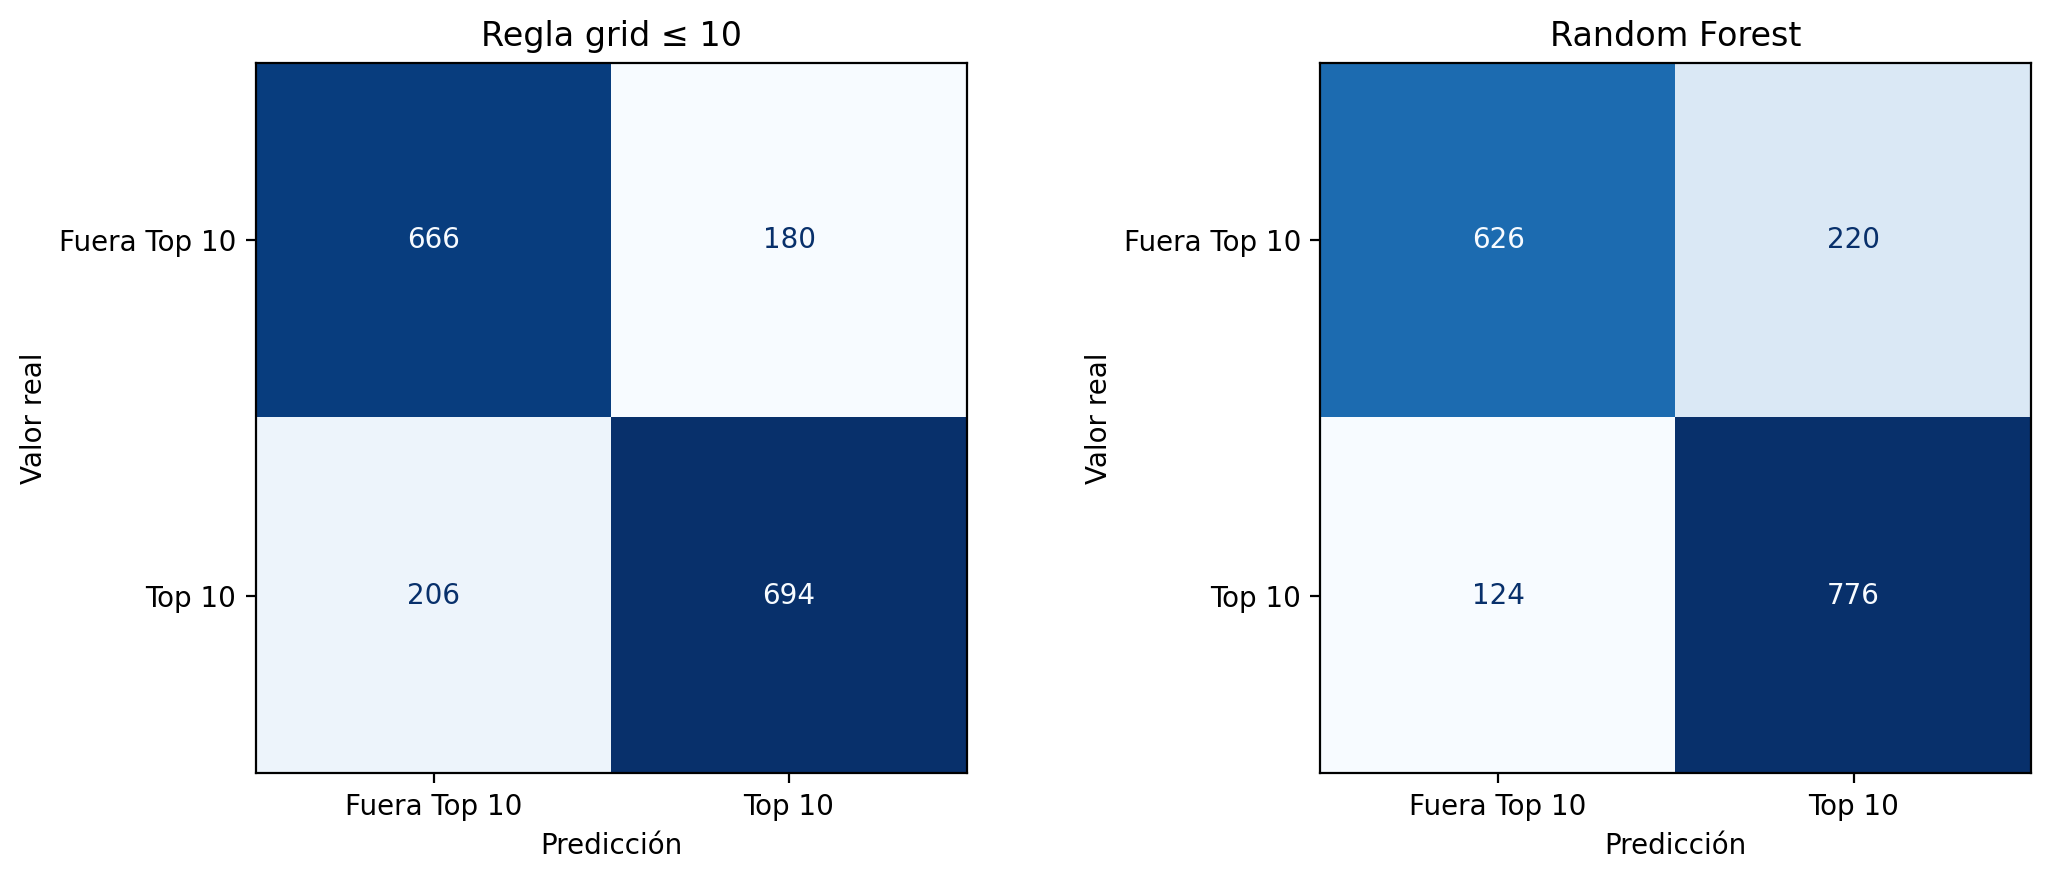

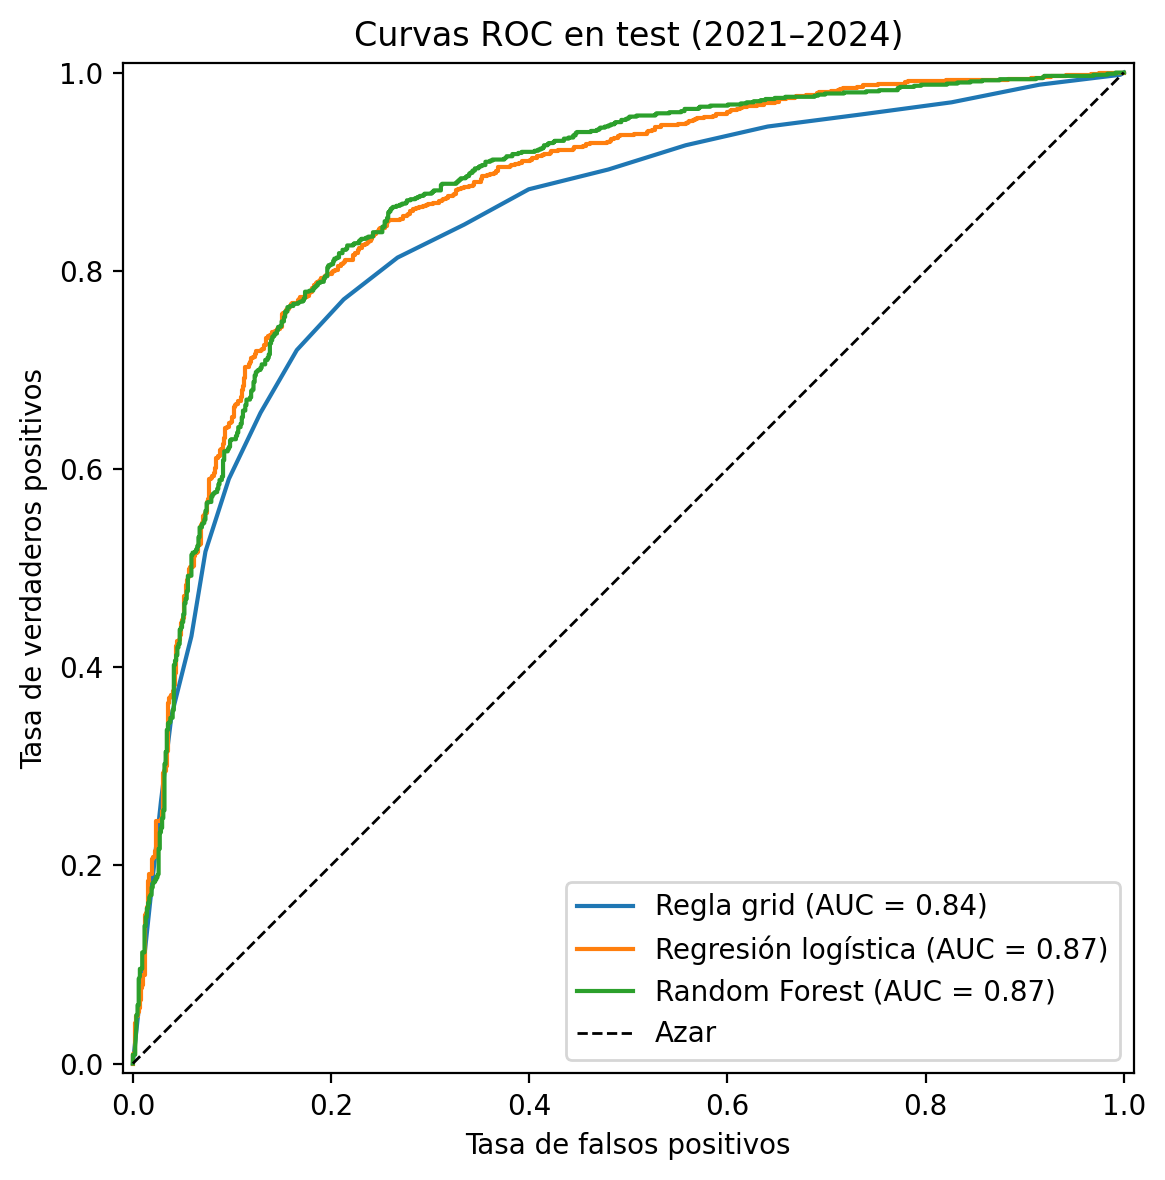

In [ ]:
from sklearn.base import clone
from sklearn.metrics import (roc_auc_score, accuracy_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)

# Modelo final
rf_final = clone(modelo_rf).set_params(clf__max_depth=4, clf__min_samples_leaf=50).fit(X_train, y_train)
lr_final = gs_lr.best_estimator_

# Scores (probabilidades) y predicciones de clase
proba_rf = rf_final.predict_proba(X_test)[:, 1]
proba_lr = lr_final.predict_proba(X_test)[:, 1]
score_grid = -X_test["grid"]

pred_rf = rf_final.predict(X_test)
pred_lr = lr_final.predict(X_test)
pred_grid = (X_test["grid"] <= 10).astype(int)

# 1) Resumen de métricas
resumen = pd.DataFrame({
    "AUC test": [roc_auc_score(y_test, s) for s in [score_grid, proba_lr, proba_rf]],
    "Accuracy test": [accuracy_score(y_test, p) for p in [pred_grid, pred_lr, pred_rf]],
}, index=["Regla grid ≤ 10", "Regresión logística", "Random Forest"])
print(resumen.round(3))

# 2) Classification report: modelo final y referencia
print("\nRandom Forest\n", classification_report(y_test, pred_rf,
      target_names=["Fuera Top 10", "Top 10"]))
print("Regla grid ≤ 10\n", classification_report(y_test, pred_grid,
      target_names=["Fuera Top 10", "Top 10"]))

# 3) Matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, titulo in zip(axes, [pred_grid, pred_rf], ["Regla grid ≤ 10", "Random Forest"]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=["Fuera Top 10", "Top 10"],
        cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
plt.tight_layout()
plt.show()

# 4) Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(6.5, 6))
for score, nombre in zip([score_grid, proba_lr, proba_rf],
                         ["Regla grid", "Regresión logística", "Random Forest"]):
    RocCurveDisplay.from_predictions(y_test, score, name=nombre, ax=ax)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Azar")
ax.set_title("Curvas ROC en test (2021–2024)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Resumen**

El modelo final se evaluó una única vez sobre las temporadas 2021–2024 (1.746 filas, 90 carreras), no utilizadas en ninguna etapa previa.

| Modelo | AUC test | Accuracy test |
|---|---|---|
| Regla grid ≤ 10 | 0,840 | 0,779 |
| Regresión logística | 0,869 | 0,797 |
| Random Forest | 0,871 | 0,803 |

El AUC en test es superior al de validación cruzada (0,816), pero la regla basada en `grid` también mejora (de 0,806 a 0,840). El aumento se explica principalmente porque 2021–2024 es un período más predecible que el promedio de validación, y no por un mejor desempeño del modelo. La comparación relevante es contra la regla simple dentro del mismo período: ambos modelos la superan por ~0,03 de AUC, una mejora mayor que la observada en validación. En cambio, la diferencia entre Random Forest y regresión logística (0,002) no es relevante, por lo que la ventaja del Random Forest observada en validación no se confirma en test.

Las matrices de confusión muestran que el Random Forest mejora principalmente en los pilotos que largan fuera del Top 10 y terminan dentro: reduce los falsos negativos de 206 a 124, a costa de 40 falsos positivos adicionales. El recall de la clase Top 10 sube de 0,77 a 0,86 con una precisión similar (0,78 frente a 0,79). Ambos modelos superan ampliamente la accuracy de referencia de predecir siempre Top 10 (51,5%).

## Interpretabilidad del modelo

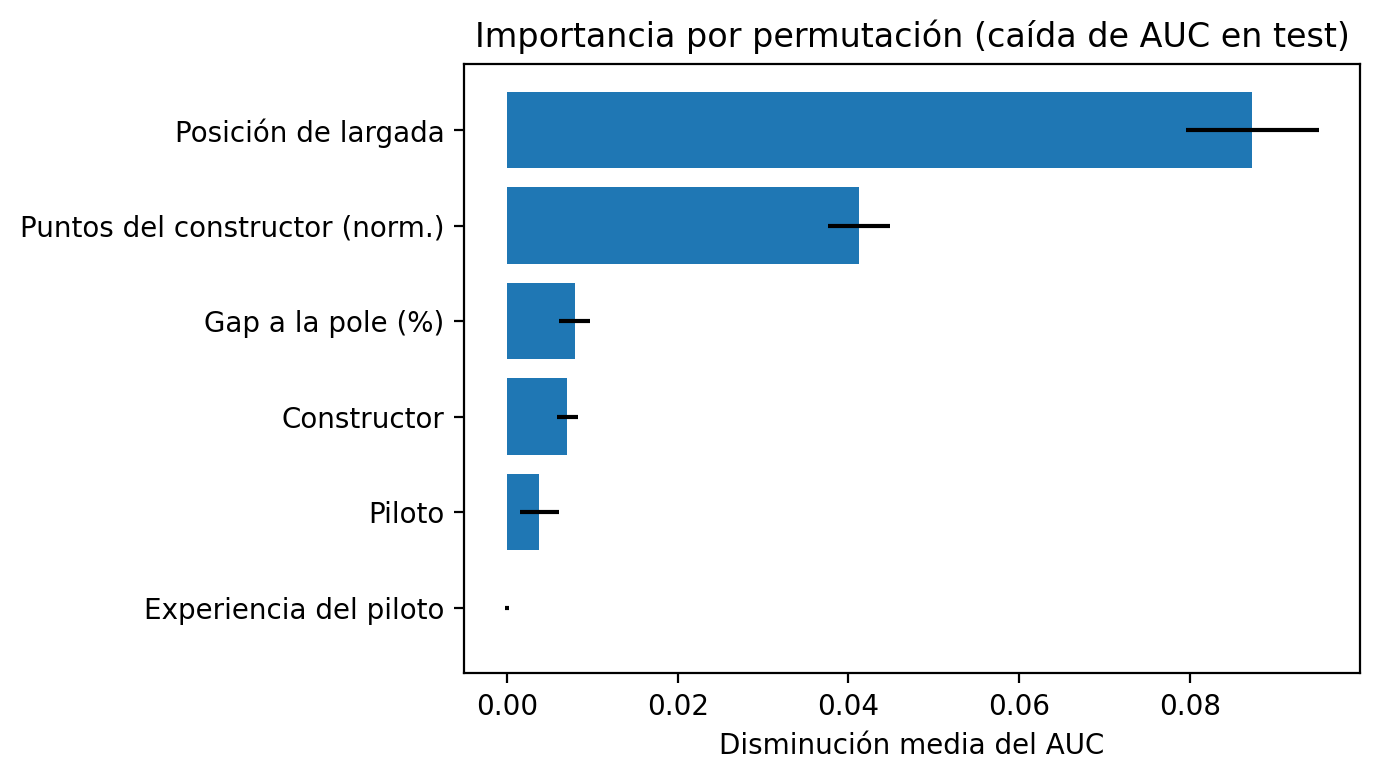

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf_final, X_test, y_test, scoring="roc_auc",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
nombres = {
    "grid": "Posición de largada",
    "pts_constructor_norm": "Puntos del constructor (norm.)",
    "gap_pct": "Gap a la pole (%)",
    "constructorId": "Constructor",
    "driverId": "Piloto",
    "experiencia": "Experiencia del piloto",
}

imp = pd.Series(perm.importances_mean, index=X_test.columns)
err = pd.Series(perm.importances_std, index=X_test.columns)
orden = imp.sort_values().index
imp = imp[orden].rename(index=nombres)
err = err[orden].rename(index=nombres)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp.index, imp.values, xerr=err.values)
ax.set_title("Importancia por permutación (caída de AUC en test)")
ax.set_xlabel("Disminución media del AUC")
plt.tight_layout()
plt.show()

**Interpretabilidad: importancia por permutación**

Se midió la importancia de cada feature como la caída del AUC en test al desordenar aleatoriamente sus valores (10 repeticiones). A diferencia de la importancia por impureza del Random Forest, este método no está sesgado hacia variables continuas o de alta cardinalidad..

La posición de largada es la feature más importante (caída de 0,09 de AUC), seguida por los puntos normalizados del constructor (~0,04). El resto de las variables tiene un aporte menor a 0,01, y la experiencia del piloto no aporta información al modelo, lo que coincide con su coeficiente prácticamente nulo en la regresión logística.

Esto precisa el análisis de redundancia de la etapa de modelado: la información adicional que el modelo incorpora sobre `grid` proviene principalmente de `pts_constructor_norm`, que permite identificar autos competitivos que largan atrás. La baja importancia de `constructorId` y `gap_pct` no implica que carezcan de información, sino que esta ya está contenida en `pts_constructor_norm` y `grid`, respectivamente: con features correlacionadas, el modelo se apoya en una y la otra aparece como poco importante.

# 8. Conclusiones, insights y limitaciones

## Conclusiones

**Respuesta a la pregunta del proyecto.** Con información disponible antes de la largada, es posible predecir si un piloto terminará en el Top 10 con un AUC de 0,87 y una accuracy del 80% en las temporadas 2021–2024, frente al 51,5% de predecir siempre la clase mayoritaria.

**La posición de largada concentra la mayor parte del poder predictivo.** Una regla simple sin entrenamiento ("Top 10 si larga entre los 10 primeros") alcanza un AUC de 0,806 en validación y 0,840 en test. La regresión logística no la supera en validación, y un modelo sin `grid` recupera cerca del 89% de su poder de discriminación por encima del azar. Las features históricas son mayormente redundantes con la posición de largada, que ya resume la competitividad del auto y del piloto en ese fin de semana. La excepción son los puntos normalizados del constructor, que explican la mayor parte de la mejora de los modelos sobre la regla simple.

**El aporte de los modelos está en detectar autos competitivos que largan atrás.** En validación, el Random Forest regularizado igualó o superó a la regla simple en los cinco folds (mejora media de 0,01 de AUC). En test, ambos modelos la superaron por aproximadamente 0,03. La mejora se concentra en los pilotos que largan fuera del Top 10 y terminan dentro: el Random Forest reduce estos casos no detectados de 206 a 124, a costa de 40 falsos positivos adicionales. La importancia por permutación es coherente con esto: después de `grid` (caída de 0,09 de AUC), la feature más relevante es `pts_constructor_norm` (~0,04), que indica cuándo un auto que larga atrás es en realidad competitivo. El resto de las variables aporta menos de 0,01, y la experiencia del piloto no aporta información.

**Random Forest y regresión logística tienen un desempeño equivalente en test.** La ventaja del Random Forest en validación (~0,008 de AUC) prácticamente desaparece en test (0,002). Dado que la regresión logística es más simple e interpretable, sería una alternativa igualmente válida como modelo final.

**La complejidad sin control empeora los resultados.** El Random Forest con hiperparámetros por defecto obtuvo el peor desempeño de todos (AUC 0,775), por debajo incluso de la regla simple, debido a sobreajuste (AUC ~0,97 en entrenamiento): memorizaba el componente aleatorio del target, como abandonos e incidentes. Solo tras regularizarlo superó a los demás enfoques, y todas las configuraciones regularizadas obtuvieron resultados prácticamente iguales. Lo que mejoró el modelo fue controlar la varianza, no el ajuste fino de hiperparámetros.

**La predictibilidad depende de la época.** El AUC de la regla de `grid` pasa de 0,73 (1998–2003) a 0,84–0,85 en los períodos más recientes, y el AUC en test (0,87) supera al de validación (0,82) porque 2021–2024 es un período más predecible, no por un mejor desempeño del modelo. Una explicación posible es la menor tasa de abandonos en la era moderna, que hace que la posición de largada se traduzca con más fidelidad en el resultado. Esta explicación no fue verificada.

**El diseño de la validación fue determinante para obtener métricas confiables.** Las features históricas se construyeron con corte temporal estricto (solo información previa a cada carrera), se descartaron variables que se generan durante la carrera, y la evaluación se realizó con un split temporal en lugar de uno aleatorio. Un split aleatorio habría permitido que el Target Encoding de pilotos y constructores usara información de temporadas futuras, inflando las métricas. El resultado es una estimación realista del desempeño al predecir carreras nuevas a partir del pasado.

## Limitaciones

- **Datos.** Base Ergast obtenida vía Kaggle: datos comunitarios, no oficiales de la FIA/F1. Los tiempos de clasificación faltan en el 57–94% de las filas entre 1996 y 2002, por lo que `gap_pct` aporta poca información en ese período.
- **Definición del target.** "Top 10" solo coincide con la zona de puntos desde 2010. Para temporadas anteriores, el target no representa sumar puntos, sino un umbral fijo de rendimiento.
- **Puntos de sprint.** Los puntos acumulados se calcularon con los resultados de carreras principales. Las carreras sprint (desde 2021) se registran en una tabla separada y no se incluyeron, por lo que los puntos del constructor están subestimados en el período de test. La normalización por el líder atenúa, pero no elimina, este efecto.
- **Continuidad de equipos.** Cada identidad de constructor (por ejemplo, Jordan, Force India, Racing Point y Aston Martin) se trató como una categoría distinta, perdiendo la continuidad de la estructura técnica del equipo.
- **Evaluación.** El test cubre un único período de cuatro temporadas (90 carreras), más predecible que el promedio histórico. No se calcularon intervalos de confianza para las métricas de test ni se aplicaron tests estadísticos formales sobre las diferencias entre modelos, ya que los folds temporales comparten datos de entrenamiento y no son independientes.
- **Estructura del problema.** El modelo predice cada piloto de forma independiente, sin imponer que haya exactamente 10 pilotos en el Top 10 por carrera. En una misma carrera puede predecir más o menos de 10.
- **Umbral.** Se usó el umbral por defecto de 0,5, sin optimizarlo según un objetivo específico (priorizar precisión o recall).
- **Interpretación de importancias.** Las features están correlacionadas entre sí, por lo que ni los coeficientes de la regresión logística ni la importancia por permutación deben leerse como el efecto aislado de cada variable. Una feature puede aparecer como poco importante porque su información ya está contenida en otra.
- **Variables no incluidas.** El clima no está disponible en el dataset, y el circuito se excluyó por no mostrar señal marginal sobre el target.

## Trabajo futuro

- **Confiabilidad del constructor:** tasa histórica de abandonos por equipo, calculada con corte temporal estricto. Es información que `grid` no contiene y que determina si un piloto termina la carrera.
- **Penalizaciones de grilla:** diferencia entre la posición de clasificación y la posición de largada, para identificar autos competitivos que largan atrás, que es el caso donde los modelos superan a la regla simple.
- **Simplificación del modelo:** evaluar un modelo reducido con `grid` y `pts_constructor_norm`, dado que el resto de las features aporta poco, y eliminar `experiencia`, cuyo aporte es nulo.
- **Interacción circuito × constructor,** para captar equipos que rinden distinto según el tipo de trazado.
- **Incorporar datos de clima** de fuentes externas.
- **Enfoque de ranking por carrera:** ordenar a los pilotos de cada carrera según su probabilidad y asignar el Top 10 a los 10 primeros, respetando la estructura del problema.
- **Verificar las hipótesis planteadas:** la relación entre la tasa de abandonos y la predictibilidad por época, y el efecto del cambio de reglamento de 2009 en el desempeño de la regresión logística.
- **Intervalos de confianza** para las métricas de test.